In [2]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/New Site Prediction trial ML update grouping.csv") #read data csv

In [ ]:
# set the for show max columns
pd.set_option('display.max_columns', None)

Exploratory Data Analysis (EDA)

In [ ]:
df.head()

,SITE_ID,Long,Lat,Objective,COLLO/B2S,Antenna_Height,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,Nearest_Existing Site,ISD,Revenue_Nearest_Site,Population,Target_Variable,Revenue,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,POI,Number_of_Retailer,Kel_Des,PopCov_4G,Kab_Kot,Population_Group,Antenna_Group,POI_Group
0,02TGR445,106.680536,-6.16475,New Site Capacity,COLLO,25.5,DENSE URBAN,27.79,2,"75,000,000.00",Dual Band,02TGR002,0.129409,1.203127e+08,9293.900482,1,104072197.7,0.000000,1.241376e+08,0.290742,25,1,1,1,Healthcare,95,PORIS JAYA,100.000004,KOTA TANGERANG,3000-10000,25-35,Pareto 3
1,02TGR446,106.713680,-6.19394,New Site Capacity,COLLO,40.0,DENSE URBAN,27.79,2,"75,000,000.00",Triple Band,02TGR059,0.450200,1.916844e+08,4899.189422,1,85764466.57,0.447421,9.378769e+07,0.004002,25,1,1,1,Attraction and Recreation,56,PARUNG JAYA,100.000004,KOTA TANGERANG,3000-10000,35-50,Pareto 4
2,02TGX377,106.613120,-6.12976,New Site Coverage,COLLO,34.5,URBAN,29.42,1,"75,000,000.00",Dual Band,02TGX165,1.151174,5.574641e+07,13587.666540,1,119375537.9,0.355257,0.000000e+00,0.853693,9,1,1,1,Gourmet,46,KEDAUNG BARAT,100.000001,TANGERANG,3000-10000,25-35,Pareto 4
3,02TGR448,106.698320,-6.22764,New Site Capacity,COLLO,27.0,DENSE URBAN,27.79,2,"75,000,000.00",Triple Band,02TGN321,0.121706,1.233976e+08,5260.934467,1,112105841.9,0.315551,1.212586e+08,0.138083,25,1,1,1,Shopping,45,SUDIMARA SELATAN,100.000004,KOTA TANGERANG,3000-10000,25-35,Pareto 4
4,02TGR449,106.737220,-6.22858,New Site Capacity,COLLO,30.0,DENSE URBAN,27.79,2,"75,000,000.00",Dual Band,02TGR189,0.137218,1.242217e+08,3616.657548,1,98540030.5,0.000157,1.332327e+08,0.078566,25,1,1,1,Education,35,KREO,100.000004,KOTA TANGERANG,3000-10000,25-35,Pareto 1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3470 entries, 0 to 3469
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SITE_ID                    3470 non-null   object 
 1   Long                       3470 non-null   float64
 2   Lat                        3470 non-null   float64
 3   Objective                  3470 non-null   object 
 4   COLLO/B2S                  3470 non-null   object 
 5   Antenna_Height             3463 non-null   float64
 6   Clutter                    3470 non-null   object 
 7   FB_Market_Share_MC         3470 non-null   float64
 8   Ranking_Market_Share       3470 non-null   int64  
 9   Target_Revenue             3470 non-null   object 
 10  Config_PO                  3470 non-null   object 
 11  Nearest_Existing Site      3470 non-null   object 
 12  ISD                        3470 non-null   float64
 13  Revenue_Nearest_Site       3470 non-null   float

In [ ]:
data = df.set_index(['SITE_ID']) #create new data frame and assign customer id as data index

In [ ]:
data.head()

,Long,Lat,Objective,COLLO/B2S,Antenna_Height,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,Nearest_Existing Site,ISD,Revenue_Nearest_Site,Population,Target_Variable,Revenue,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,POI,Number_of_Retailer,Kel_Des,PopCov_4G,Kab_Kot,Population_Group,Antenna_Group,POI_Group
SITE_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
02TGR445,106.680536,-6.16475,New Site Capacity,COLLO,25.5,DENSE URBAN,27.79,2,"75,000,000.00",Dual Band,02TGR002,0.129409,1.203127e+08,9293.900482,1,104072197.7,0.000000,1.241376e+08,0.290742,25,1,1,1,Healthcare,95,PORIS JAYA,100.000004,KOTA TANGERANG,3000-10000,25-35,Pareto 3
02TGR446,106.713680,-6.19394,New Site Capacity,COLLO,40.0,DENSE URBAN,27.79,2,"75,000,000.00",Triple Band,02TGR059,0.450200,1.916844e+08,4899.189422,1,85764466.57,0.447421,9.378769e+07,0.004002,25,1,1,1,Attraction and Recreation,56,PARUNG JAYA,100.000004,KOTA TANGERANG,3000-10000,35-50,Pareto 4
02TGX377,106.613120,-6.12976,New Site Coverage,COLLO,34.5,URBAN,29.42,1,"75,000,000.00",Dual Band,02TGX165,1.151174,5.574641e+07,13587.666540,1,119375537.9,0.355257,0.000000e+00,0.853693,9,1,1,1,Gourmet,46,KEDAUNG BARAT,100.000001,TANGERANG,3000-10000,25-35,Pareto 4
02TGR448,106.698320,-6.22764,New Site Capacity,COLLO,27.0,DENSE URBAN,27.79,2,"75,000,000.00",Triple Band,02TGN321,0.121706,1.233976e+08,5260.934467,1,112105841.9,0.315551,1.212586e+08,0.138083,25,1,1,1,Shopping,45,SUDIMARA SELATAN,100.000004,KOTA TANGERANG,3000-10000,25-35,Pareto 4
02TGR449,106.737220,-6.22858,New Site Capacity,COLLO,30.0,DENSE URBAN,27.79,2,"75,000,000.00",Dual Band,02TGR189,0.137218,1.242217e+08,3616.657548,1,98540030.5,0.000157,1.332327e+08,0.078566,25,1,1,1,Education,35,KREO,100.000004,KOTA TANGERANG,3000-10000,25-35,Pareto 1


In [ ]:
data.drop('Antenna_Height', inplace=True, axis=1)

In [ ]:
data.drop('Kel_Des', inplace=True, axis=1)

In [ ]:
data.drop('Kab_Kot', inplace=True, axis=1)

In [ ]:
data.drop('Revenue', inplace=True, axis=1)

In [ ]:
data.drop('Population', inplace=True, axis=1)

In [ ]:
data.drop('Nearest_Existing Site', inplace=True, axis=1)

In [ ]:
data.drop('POI', inplace=True, axis=1)

In [ ]:
data.head()

,Long,Lat,Objective,COLLO/B2S,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,ISD,Revenue_Nearest_Site,Target_Variable,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,Number_of_Retailer,PopCov_4G,Population_Group,Antenna_Group,POI_Group
SITE_ID,,,,,,,,,,,,,,,,,,,,,,,,
02TGR445,106.680536,-6.16475,New Site Capacity,COLLO,DENSE URBAN,27.79,2,"75,000,000.00",Dual Band,0.129409,1.203127e+08,1,0.000000,1.241376e+08,0.290742,25,1,1,1,95,100.000004,3000-10000,25-35,Pareto 3
02TGR446,106.713680,-6.19394,New Site Capacity,COLLO,DENSE URBAN,27.79,2,"75,000,000.00",Triple Band,0.450200,1.916844e+08,1,0.447421,9.378769e+07,0.004002,25,1,1,1,56,100.000004,3000-10000,35-50,Pareto 4
02TGX377,106.613120,-6.12976,New Site Coverage,COLLO,URBAN,29.42,1,"75,000,000.00",Dual Band,1.151174,5.574641e+07,1,0.355257,0.000000e+00,0.853693,9,1,1,1,46,100.000001,3000-10000,25-35,Pareto 4
02TGR448,106.698320,-6.22764,New Site Capacity,COLLO,DENSE URBAN,27.79,2,"75,000,000.00",Triple Band,0.121706,1.233976e+08,1,0.315551,1.212586e+08,0.138083,25,1,1,1,45,100.000004,3000-10000,25-35,Pareto 4
02TGR449,106.737220,-6.22858,New Site Capacity,COLLO,DENSE URBAN,27.79,2,"75,000,000.00",Dual Band,0.137218,1.242217e+08,1,0.000157,1.332327e+08,0.078566,25,1,1,1,35,100.000004,3000-10000,25-35,Pareto 1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3470 entries, 02TGR445 to 11MEN107
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Long                       3470 non-null   float64
 1   Lat                        3470 non-null   float64
 2   Objective                  3470 non-null   object 
 3   COLLO/B2S                  3470 non-null   object 
 4   Clutter                    3470 non-null   object 
 5   FB_Market_Share_MC         3470 non-null   float64
 6   Ranking_Market_Share       3470 non-null   int64  
 7   Target_Revenue             3470 non-null   object 
 8   Config_PO                  3470 non-null   object 
 9   ISD                        3470 non-null   float64
 10  Revenue_Nearest_Site       3470 non-null   float64
 11  Target_Variable            3470 non-null   int64  
 12  Distance_to_XL_Competitor  3470 non-null   float64
 13  Revenue_XL                 3470 non-null  

Data Wrangling

In [ ]:
#data.Antenna_Height.isnull().sum() #Cek Null Values on Antenna Height

7

In [ ]:
# mean AH , ambil mean value 
#mean_AH=data['Antenna_Height'].mean()

In [ ]:
#print (mean_AH)

47.004467224949465


In [ ]:
#data.loc[(data.Antenna_Height.isnull()),'Antenna_Height']= mean_AH

In [ ]:
#data.Population.isnull().sum() #Cek Null Values on Antenna Height

32

In [ ]:
# mean Pop , ambil mean value 
#mean_Pop=data['Population'].mean()

In [ ]:
#print (mean_Pop)

8155.114062497673


In [ ]:
#data.loc[(data.Population.isnull()),'Population']= mean_Pop

In [ ]:
df.POI_Group.value_counts()

Pareto 1    2327
Pareto 2     512
Pareto 3     364
Pareto 4     265
Name: POI_Group, dtype: int64

In [ ]:
data.loc[(data.POI_Group.isnull()),'POI_Group']= 'Pareto 4'

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3470 entries, 02TGR445 to 11MEN107
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Long                       3470 non-null   float64
 1   Lat                        3470 non-null   float64
 2   Objective                  3470 non-null   object 
 3   COLLO/B2S                  3470 non-null   object 
 4   Clutter                    3470 non-null   object 
 5   FB_Market_Share_MC         3470 non-null   float64
 6   Ranking_Market_Share       3470 non-null   int64  
 7   Target_Revenue             3470 non-null   object 
 8   Config_PO                  3470 non-null   object 
 9   ISD                        3470 non-null   float64
 10  Revenue_Nearest_Site       3470 non-null   float64
 11  Target_Variable            3470 non-null   int64  
 12  Distance_to_XL_Competitor  3470 non-null   float64
 13  Revenue_XL                 3470 non-null  

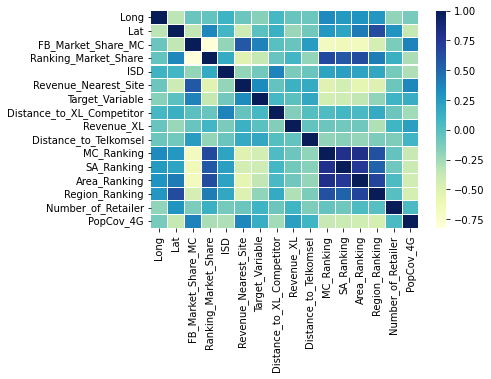

In [ ]:
corr = data.corr()
sns.heatmap(corr, cmap='YlGnBu', linewidths='0.1')

In [ ]:
corr.style.background_gradient(cmap='YlGnBu')

,Long,Lat,FB_Market_Share_MC,Ranking_Market_Share,ISD,Revenue_Nearest_Site,Target_Variable,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,Number_of_Retailer,PopCov_4G
Long,1.000000,-0.339607,-0.055655,-0.035525,0.105908,-0.075370,-0.167512,0.068213,-0.050915,-0.064548,0.345700,0.259024,0.295396,0.276651,-0.196294,-0.118673
Lat,-0.339607,1.000000,-0.352147,0.355496,0.087338,-0.398710,-0.010592,0.128199,-0.225518,-0.087302,0.266235,0.203601,0.414731,0.640312,0.290599,-0.368258
FB_Market_Share_MC,-0.055655,-0.352147,1.000000,-0.824831,-0.203449,0.577035,0.386809,-0.000701,-0.048986,0.250448,-0.668085,-0.633869,-0.666388,-0.446133,-0.128897,0.372852
Ranking_Market_Share,-0.035525,0.355496,-0.824831,1.000000,0.160717,-0.519486,-0.366853,-0.051341,0.082451,-0.202565,0.656996,0.576660,0.639611,0.408296,0.130068,-0.277701
ISD,0.105908,0.087338,-0.203449,0.160717,1.000000,-0.203432,-0.092735,0.377008,-0.122058,-0.055521,0.206003,0.224371,0.209859,0.173517,-0.105496,-0.289325
Revenue_Nearest_Site,-0.075370,-0.398710,0.577035,-0.519486,-0.203432,1.000000,0.341067,-0.047618,0.117365,0.159446,-0.507532,-0.437870,-0.543813,-0.491642,-0.065670,0.356632
Target_Variable,-0.167512,-0.010592,0.386809,-0.366853,-0.092735,0.341067,1.000000,0.072855,-0.005283,0.179151,-0.438084,-0.408870,-0.352643,-0.192289,0.100930,0.139052
Distance_to_XL_Competitor,0.068213,0.128199,-0.000701,-0.051341,0.377008,-0.047618,0.072855,1.000000,-0.153061,0.011306,0.033244,0.073678,0.052751,0.160515,-0.074183,-0.252205
Revenue_XL,-0.050915,-0.225518,-0.048986,0.082451,-0.122058,0.117365,-0.005283,-0.153061,1.000000,-0.035838,-0.075901,-0.087872,-0.077461,-0.291163,0.094354,0.223285
Distance_to_Telkomsel,-0.064548,-0.087302,0.250448,-0.202565,-0.055521,0.159446,0.179151,0.011306,-0.035838,1.000000,-0.194560,-0.165525,-0.206843,-0.132384,-0.135861,0.092337


In [ ]:
num = ['Objective', 'COLLO/B2S', 'Antenna_Group','Clutter', 'FB_Market_Share_MC', 'Ranking_Market_Share',
       'Target_Revenue','Revenue_Nearest_Site','ISD','Config_PO','POI_Group','Population_Group']

In [ ]:
def exp2(columns):
    sns.histplot(data=data, x=columns, hue='Target_Variable',multiple = "stack", palette = "YlOrBr")
    plt.show()

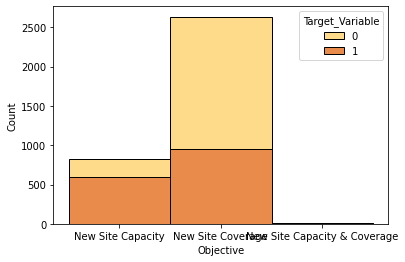

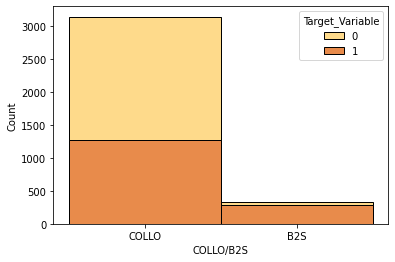

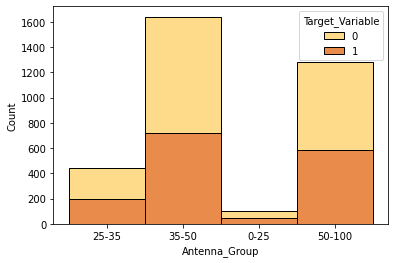

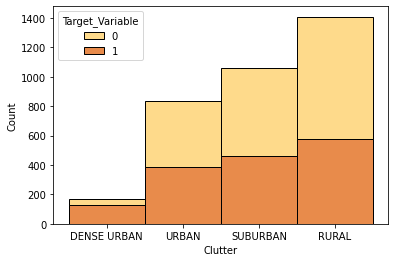

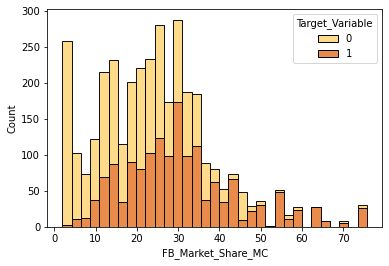

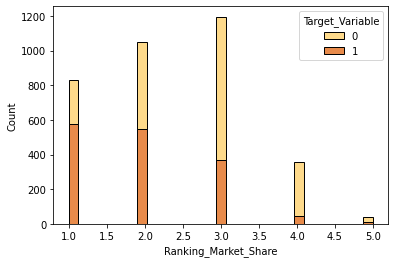

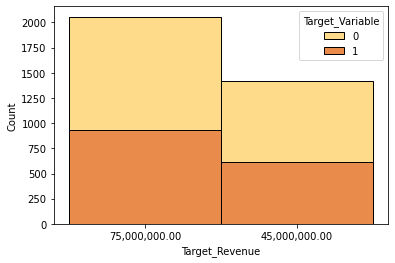

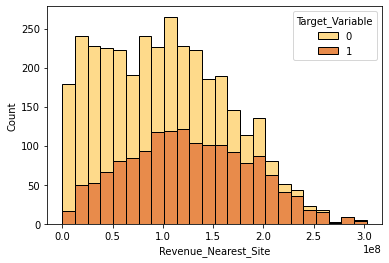

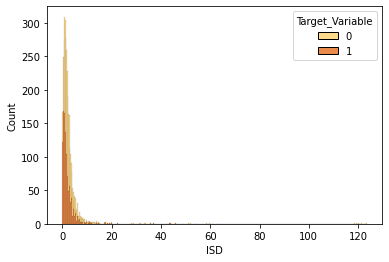

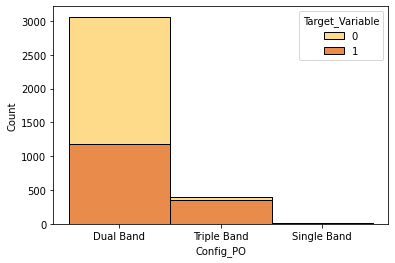

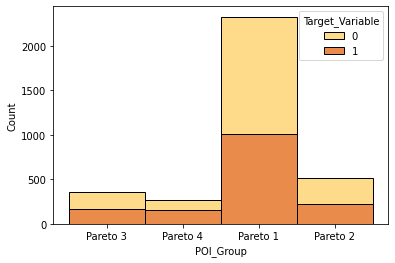

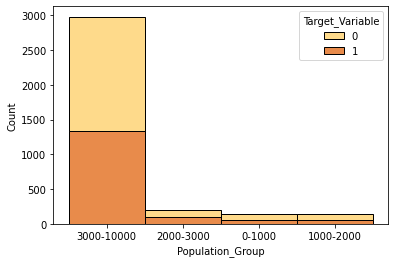

In [ ]:
for feature in num:
    exp2(feature)

Feature Engineering

In [ ]:
obj = ['Objective', 'COLLO/B2S','Clutter','Target_Revenue','Config_PO','POI_Group','Antenna_Group','Population_Group']

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

for col in obj:
    data[col] = labelencoder.fit_transform(data[col])

data.head()

,Long,Lat,Objective,COLLO/B2S,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,ISD,Revenue_Nearest_Site,Target_Variable,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,Number_of_Retailer,PopCov_4G,Population_Group,Antenna_Group,POI_Group
SITE_ID,,,,,,,,,,,,,,,,,,,,,,,,
02TGR445,106.680536,-6.16475,0,1,0,27.79,2,1,0,0.129409,1.203127e+08,1,0.000000,1.241376e+08,0.290742,25,1,1,1,95,100.000004,3,1,2
02TGR446,106.713680,-6.19394,0,1,0,27.79,2,1,2,0.450200,1.916844e+08,1,0.447421,9.378769e+07,0.004002,25,1,1,1,56,100.000004,3,2,3
02TGX377,106.613120,-6.12976,2,1,3,29.42,1,1,0,1.151174,5.574641e+07,1,0.355257,0.000000e+00,0.853693,9,1,1,1,46,100.000001,3,1,3
02TGR448,106.698320,-6.22764,0,1,0,27.79,2,1,2,0.121706,1.233976e+08,1,0.315551,1.212586e+08,0.138083,25,1,1,1,45,100.000004,3,1,3
02TGR449,106.737220,-6.22858,0,1,0,27.79,2,1,0,0.137218,1.242217e+08,1,0.000157,1.332327e+08,0.078566,25,1,1,1,35,100.000004,3,1,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3470 entries, 02TGR445 to 11MEN107
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Long                       3470 non-null   float64
 1   Lat                        3470 non-null   float64
 2   Objective                  3470 non-null   int64  
 3   COLLO/B2S                  3470 non-null   int64  
 4   Clutter                    3470 non-null   int64  
 5   FB_Market_Share_MC         3470 non-null   float64
 6   Ranking_Market_Share       3470 non-null   int64  
 7   Target_Revenue             3470 non-null   int64  
 8   Config_PO                  3470 non-null   int64  
 9   ISD                        3470 non-null   float64
 10  Revenue_Nearest_Site       3470 non-null   float64
 11  Target_Variable            3470 non-null   int64  
 12  Distance_to_XL_Competitor  3470 non-null   float64
 13  Revenue_XL                 3470 non-null  

In [ ]:
corr=data.corr()
corr.style.background_gradient(cmap='YlGnBu')

,Long,Lat,Objective,COLLO/B2S,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,ISD,Revenue_Nearest_Site,Target_Variable,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,Number_of_Retailer,PopCov_4G,Population_Group,Antenna_Group,POI_Group
Long,1.000000,-0.339607,0.076987,0.078186,0.227662,-0.055655,-0.035525,0.129098,-0.082250,0.105908,-0.075370,-0.167512,0.068213,-0.050915,-0.064548,0.345700,0.259024,0.295396,0.276651,-0.196294,-0.118673,0.044247,-0.015759,-0.074573
Lat,-0.339607,1.000000,0.290422,0.115205,-0.438288,-0.352147,0.355496,-0.863972,-0.198261,0.087338,-0.398710,-0.010592,0.128199,-0.225518,-0.087302,0.266235,0.203601,0.414731,0.640312,0.290599,-0.368258,-0.221342,0.068105,-0.091698
Objective,0.076987,0.290422,1.000000,0.280336,-0.151603,-0.361083,0.387621,-0.393840,-0.487220,0.142457,-0.419315,-0.305853,0.062065,-0.089008,-0.149509,0.439486,0.404479,0.450599,0.465592,-0.069833,-0.267272,-0.080054,0.174573,-0.143791
COLLO/B2S,0.078186,0.115205,0.280336,1.000000,-0.084433,-0.326056,0.249254,-0.138389,-0.340753,0.074918,-0.257851,-0.263832,-0.054259,-0.000881,-0.320518,0.243782,0.224740,0.219150,0.234640,0.016888,-0.139003,-0.001728,-0.007024,0.008007
Clutter,0.227662,-0.438288,-0.151603,-0.084433,1.000000,0.219473,-0.209524,0.459894,0.105011,-0.054836,0.224424,-0.030252,-0.116447,0.137024,0.085597,-0.116580,-0.103201,-0.227460,-0.302642,-0.196542,0.231667,0.153570,-0.024330,0.054723
FB_Market_Share_MC,-0.055655,-0.352147,-0.361083,-0.326056,0.219473,1.000000,-0.824831,0.411925,0.338834,-0.203449,0.577035,0.386809,-0.000701,-0.048986,0.250448,-0.668085,-0.633869,-0.666388,-0.446133,-0.128897,0.372852,0.001353,0.013308,0.026236
Ranking_Market_Share,-0.035525,0.355496,0.387621,0.249254,-0.209524,-0.824831,1.000000,-0.400987,-0.323773,0.160717,-0.519486,-0.366853,-0.051341,0.082451,-0.202565,0.656996,0.576660,0.639611,0.408296,0.130068,-0.277701,-0.072172,0.011467,-0.041449
Target_Revenue,0.129098,-0.863972,-0.393840,-0.138389,0.459894,0.411925,-0.400987,1.000000,0.285141,-0.135625,0.476889,0.022401,-0.172542,0.291967,0.092494,-0.388897,-0.323046,-0.534360,-0.850647,-0.195867,0.442654,0.221909,-0.143187,0.168543
Config_PO,-0.082250,-0.198261,-0.487220,-0.340753,0.105011,0.338834,-0.323773,0.285141,1.000000,-0.092988,0.337988,0.322269,-0.028848,0.041881,0.135428,-0.344066,-0.310610,-0.320648,-0.370192,0.014880,0.187901,0.052992,-0.093429,0.063705
ISD,0.105908,0.087338,0.142457,0.074918,-0.054836,-0.203449,0.160717,-0.135625,-0.092988,1.000000,-0.203432,-0.092735,0.377008,-0.122058,-0.055521,0.206003,0.224371,0.209859,0.173517,-0.105496,-0.289325,0.006908,0.145580,-0.084343


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import random
X = data.drop(['Target_Variable'], axis=1)
y = data['Target_Variable']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y,random_state=1001)

In [ ]:
y_train.value_counts(normalize=True)*100

0    55.464716
1    44.535284
Name: Target_Variable, dtype: float64

In [ ]:
y_test.value_counts(normalize=True)*100

0    55.410122
1    44.589878
Name: Target_Variable, dtype: float64

In [ ]:
X_test.Region_Ranking.value_counts()

3    301
4    280
2    219
5    191
1    155
Name: Region_Ranking, dtype: int64

In [ ]:
X_train.Region_Ranking.value_counts()

3    592
4    491
2    485
5    452
1    304
Name: Region_Ranking, dtype: int64

In [ ]:
from sklearn.metrics import confusion_matrix
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf:            confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    normalize:     If True, show the proportions for each category. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html
                   
    title:         Title for the heatmap. Default is None.
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            specificity= cf[0,0]/ sum(cf[0,:])
            AUC = metrics.roc_auc_score(y_test, y_pred)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}\nSPecificity={:0.3f}\nAUC={:0.3f}".format(
                accuracy,precision,recall,f1_score,specificity,AUC)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)
    
    if title:
        plt.title(title)

Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import random
dtc = DecisionTreeClassifier(random_state = 1001)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1001)

In [ ]:
cm=confusion_matrix(y_test, dtc.predict(X_test))
y_pred=dtc.predict(X_test)

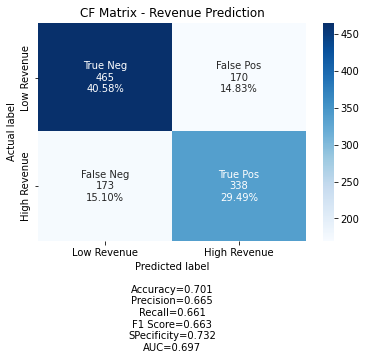

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

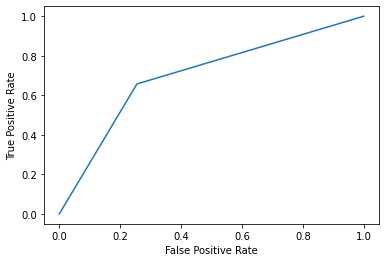

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Random Forrest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=1001)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=1001)

In [ ]:
cm=confusion_matrix(y_test, rfc.predict(X_test))
y_pred=rfc.predict(X_test)

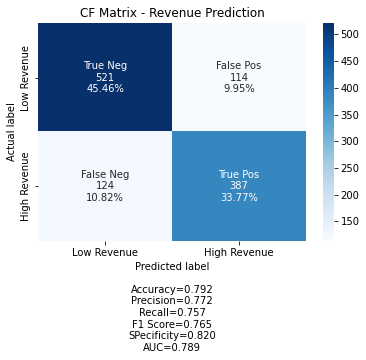

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

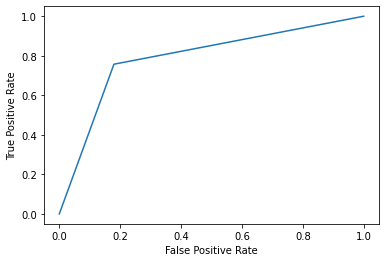

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

XG Boost

In [ ]:
!pip3 install xgboost
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',random_state=1001)
xgb.fit(X_train,y_train)

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


XGBClassifier(eval_metric='mlogloss', random_state=1001,
              use_label_encoder=False)

In [ ]:
cm=confusion_matrix(y_test, xgb.predict(X_test))
y_pred=xgb.predict(X_test)

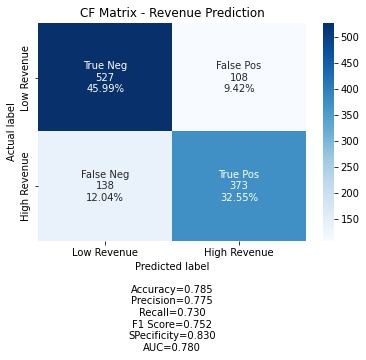

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

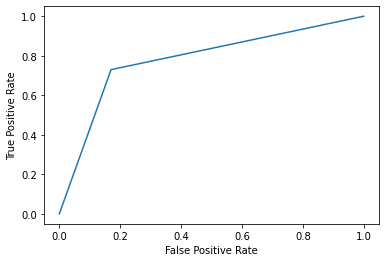

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
# save the model
import pickle
filename = 'New Site Prediction rfc_optim.sav'
pickle.dump(rfc_optim, open(filename, "wb")) #writebinary

In [ ]:
loaded_model = pickle.load(open(filename, "rb")) #readbinary

In [ ]:
clusters['prediction']=loaded_model.fit_predict(data)

XG Boost Optimization

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
params = {'n_estimator':[50, 100, 200, 300, 400, 500, 600],
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',random_state=1001)

In [ ]:
folds = 5
param_comb = 6

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

random_search = RandomizedSearchCV(xgb, param_distributions=params, n_iter=param_comb, scoring='roc_auc', n_jobs=4, cv=skf.split(X_train,y_train), verbose=3, random_state=1001 )
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


RandomizedSearchCV(cv=<generator object _BaseKFold.split at 0x7ffa1195b5d0>,
                   estimator=XGBClassifier(eval_metric='mlogloss',
                                           random_state=1001,
                                           use_label_encoder=False),
                   n_iter=6, n_jobs=4,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0.5, 1, 1.5, 2, 5],
                                        'max_depth': [3, 4, 5],
                                        'min_child_weight': [1, 5, 10],
                                        'n_estimator': [50, 100, 200, 300, 400,
                                                        500, 600],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=1001, scoring='roc_auc', verbose=3)

In [ ]:
print('\n Best estimator:')
print(random_search.best_estimator_)


 Best estimator:
XGBClassifier(colsample_bytree=0.8, eval_metric='mlogloss', gamma=1,
              max_depth=4, n_estimator=500, random_state=1001, subsample=0.8,
              use_label_encoder=False)


In [ ]:
xgb.optim =XGBClassifier(colsample_bytree=0.8, eval_metric='mlogloss', gamma=1,
              max_depth=4, n_estimator=500, random_state=1001, subsample=0.8,
              use_label_encoder=False)
xgb.optim.fit(X_train,y_train)

XGBClassifier(colsample_bytree=0.8, eval_metric='mlogloss', gamma=1,
              max_depth=4, n_estimator=500, random_state=1001, subsample=0.8,
              use_label_encoder=False)

In [ ]:
cm=confusion_matrix(y_test, xgb.optim.predict(X_test))
y_pred=xgb.optim.predict(X_test)

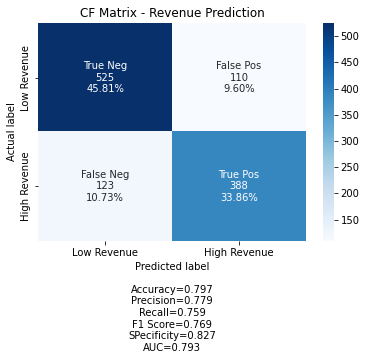

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

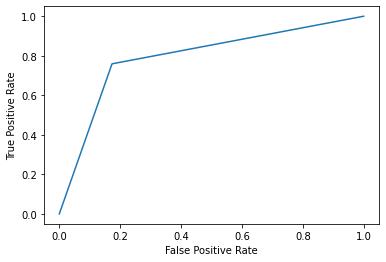

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Robust Model

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
sk_folds = StratifiedKFold(n_splits = 10)
rfc_optim1= RandomForestClassifier(random_state=1001,max_depth=  25, min_samples_leaf = 1, min_samples_split= 5, n_estimators= 300)
scores = cross_val_score(rfc_optim1, X_train, y_train, cv = sk_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.72103004 0.7639485  0.76824034 0.76824034 0.76293103 0.78017241
 0.76293103 0.77586207 0.80603448 0.74137931]
Average CV Score:  0.7650769572295397
Number of CV Scores used in Average:  10


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
sk_folds = StratifiedKFold(n_splits = 10)
scores = cross_val_score(rfc_optim1, X_test, y_test, cv = sk_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.76521739 0.79130435 0.74782609 0.82608696 0.74782609 0.74782609
 0.71052632 0.74561404 0.73684211 0.83333333]
Average CV Score:  0.7652402745995422
Number of CV Scores used in Average:  10


Random Forrest Optimization

In [ ]:
n_estimators = [100, 300, 500, 800, 1200]
max_depth = [5, 8, 15, 25, 30]
min_samples_split = [2, 5, 10, 15, 100]
min_samples_leaf = [1, 2, 5, 10] 

hyperF = dict(n_estimators = n_estimators, max_depth = max_depth,  
              min_samples_split = min_samples_split, 
             min_samples_leaf = min_samples_leaf)

from sklearn.model_selection import GridSearchCV
gridF = GridSearchCV(rfc, hyperF, cv = 5, verbose = 1, 
                      n_jobs = -1)
rfc_optim = gridF.fit(X_train, y_train)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


In [ ]:
print (rfc_optim.best_params_)

{'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("To evaluate the performace of test data on the model \n",classification_report(y_test,rfc_optim.predict(X_test)))
print("To evaluate the performance of train data on the model \n",classification_report(y_train,rfc_optim.predict(X_train)))

To evaluate the performace of test data on the model 
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       635
           1       0.78      0.77      0.78       511

    accuracy                           0.80      1146
   macro avg       0.80      0.80      0.80      1146
weighted avg       0.80      0.80      0.80      1146

To evaluate the performance of train data on the model 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1289
           1       0.99      0.99      0.99      1035

    accuracy                           0.99      2324
   macro avg       0.99      0.99      0.99      2324
weighted avg       0.99      0.99      0.99      2324



In [ ]:
cm=confusion_matrix(y_test, rfc_optim.predict(X_test))
y_pred=rfc_optim.predict(X_test)

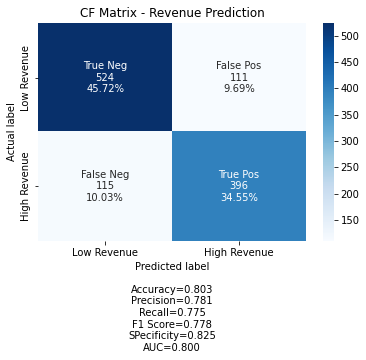

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

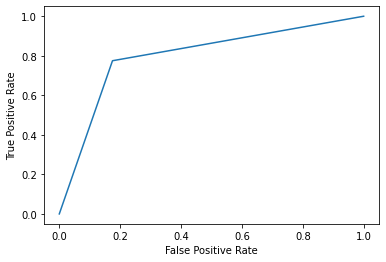

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
probas = rfc_optim.predict_proba(X_test)[:, 1]

In [ ]:
def get_preds(threshold, probabilities):
    return [1 if prob > threshold else 0 for prob in probabilities]

In [ ]:
roc_values = []
for thresh in np.linspace(0, 1, 100):
    preds = get_preds(thresh, probas)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    tpr = tp/(tp+fn)
    fpr = fp/(fp+tn)
    roc_values.append([tpr, fpr])
tpr_values, fpr_values = zip(*roc_values)

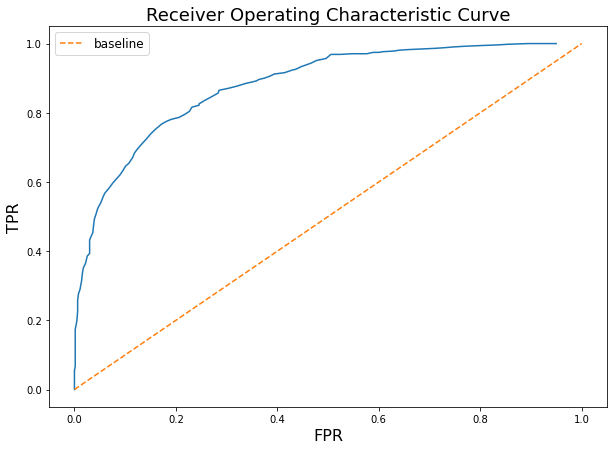

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
ax.plot(fpr_values, tpr_values)
ax.plot(np.linspace(0, 1, 100),
         np.linspace(0, 1, 100),
         label='baseline',
         linestyle='--')
plt.title('Receiver Operating Characteristic Curve', fontsize=18)
plt.ylabel('True Positive Rate', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=16)
plt.legend(fontsize=12);

Trial Neural Networks

In [ ]:
from sklearn.neural_network import MLPClassifier
nn = MLPClassifier(max_iter=100,random_state=1001)
nn.fit(X_train, y_train)

MLPClassifier(max_iter=100, random_state=1001)

In [ ]:
cm=confusion_matrix(y_test, nn.predict(X_test))
y_pred=nn.predict(X_test)

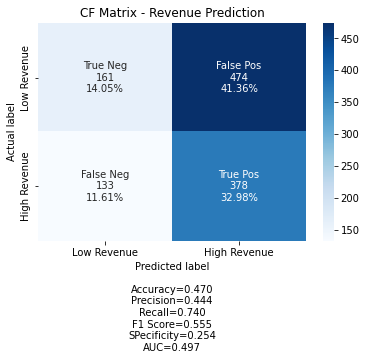

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

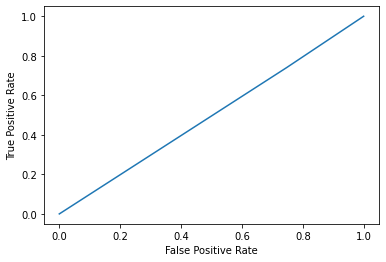

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp_gs = MLPClassifier()
parameter_space = {
    'hidden_layer_sizes': [(10,),(20,)],
    'activation': ['relu', 'sigmoid', 'softplus', 'softsign', 'tanh', 'selu','elu', 'exponential','relu'],
    'solver': ['sgd', 'adam', 'RMSprop', 'Adadelta', 'Adagrad', 'Adamax', 'Nadam', 'Ftrl'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}
from sklearn.model_selection import GridSearchCV
nn = GridSearchCV(mlp_gs, parameter_space, n_jobs=-1, cv=5)
nn.fit(X_train, y_train) # X is train samples and y is the corresponding labels

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
2640 fits failed out of a total of 2880.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 752, in fit
    return self._fit(X, y, incremental=False)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 384, in _fit
    self._validate_hyperparameters()

GridSearchCV(cv=5, estimator=MLPClassifier(), n_jobs=-1,
             param_grid={'activation': ['relu', 'sigmoid', 'softplus',
                                        'softsign', 'tanh', 'selu', 'elu',
                                        'exponential', 'relu'],
                         'alpha': [0.0001, 0.05],
                         'hidden_layer_sizes': [(10,), (20,)],
                         'learning_rate': ['constant', 'adaptive'],
                         'solver': ['sgd', 'adam', 'RMSprop', 'Adadelta',
                                    'Adagrad', 'Adamax', 'Nadam', 'Ftrl']})

In [ ]:
cm=confusion_matrix(y_test, nn.predict(X_test))
y_pred=nn.predict(X_test)

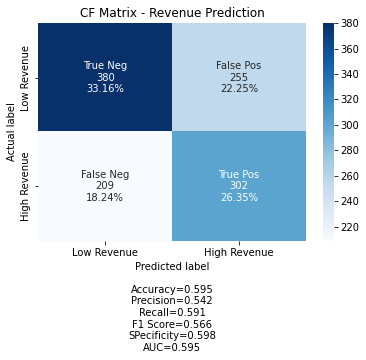

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

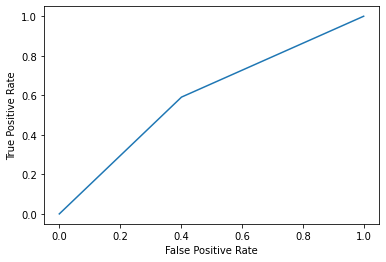

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Trial SVM


In [ ]:
from sklearn.svm import SVC
svmx=SVC(kernel='poly',random_state=1001)
svmx.fit(X_train, y_train)

SVC(kernel='poly', random_state=1001)

In [ ]:
cm=confusion_matrix(y_test, svmx.predict(X_test))
y_pred=svmx.predict(X_test)

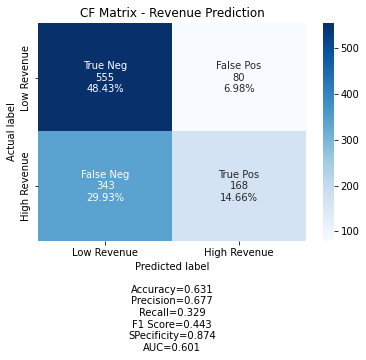

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

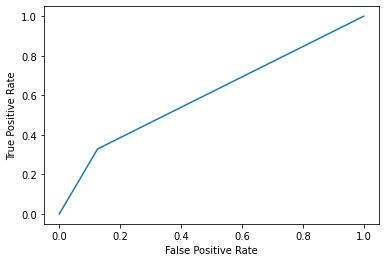

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
parameters = {'kernel':('poly','rbf'), 'C': [0.1, 1, 10, 100, 1000],'gamma': [1, 0.1, 0.01, 0.001, 0.0001],}
svmx = GridSearchCV(SVC(), parameters, refit = True, verbose = 3)
svmx.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.445 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.445 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.445 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.445 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.446 total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.555 total time=   1.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.555 total time=   0.4s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.555 total time=   0.3s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.555 total time=   0.3s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.554 total time=   0.3s
[CV 1/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.445 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.1, kernel=poly

In [ ]:
print(svmx.best_params_)

In [ ]:
cm=confusion_matrix(y_test, svmx.predict(X_test))
y_pred=svmx.predict(X_test)

In [ ]:
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Low Revenue', 'High Revenue']
make_confusion_matrix(cm, group_names=labels, categories=categories, title='CF Matrix - Revenue Prediction')

Forecasting data AOP 2023

In [ ]:
import pickle
filename = "/content/drive/MyDrive/Colab Notebooks/New Site Prediction rfc_optim.sav"
loaded_model = pickle.load(open(filename, "rb")) #readbinary

In [ ]:
df2=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/New SIte AOP 2023 Tomahawk.csv") #read data csv

In [ ]:
data2 = df2.set_index(['SITE_ID']) #create new data frame and assign customer id as data index

In [ ]:
data2.drop('Kel_Des', inplace=True, axis=1)

In [ ]:
data2.drop('Kab_Kot', inplace=True, axis=1)

In [ ]:
data2.drop('MC', inplace=True, axis=1)

In [ ]:
data2.drop('SA', inplace=True, axis=1)

In [ ]:
data2.drop('Area', inplace=True, axis=1)

In [ ]:
data2.drop('Regiom', inplace=True, axis=1)

In [ ]:
data2.drop('Nearest_Existing Site', inplace=True, axis=1)

In [ ]:
data2.drop('Revenue', inplace=True, axis=1)

In [ ]:
data2.drop('Source', inplace=True, axis=1)

In [ ]:
data2.drop('Target_Variable', inplace=True, axis=1)

In [ ]:
data2.drop('POI', inplace=True, axis=1)

In [ ]:
data2.drop('Antenna_Height', inplace=True, axis=1)

In [ ]:
data2.drop('Population', inplace=True, axis=1)

In [ ]:
data2.head()

,Long,Lat,Objective,COLLO/B2S,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,ISD,Revenue_Nearest_Site,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,Number_of_Retailer,PopCov_4G,Population_Group,Antenna_Group,POI_Group
SITE_ID,,,,,,,,,,,,,,,,,,,,,,,
13SKD101_2,105.602984,-5.513261,New Site Capacity,Collo,RURAL,34.0999,2,45000000,Triple Band,1.443868,9.876548e+07,1.471904,49133956.71,1.294287,190,25,5,4,10.0,99.055655,3000-10000,25-35,Pareto 1
03DPK492_1,106.783460,-6.403830,New Site Capacity,Collo,SUBURBAN,40.2500,1,75000000,Triple Band,0.530243,1.234381e+08,0.060486,67058819.97,0.000000,30,3,1,1,14.0,100.000001,1000-2000,25-35,Pareto 4
02SRG063_2,106.383010,-6.322560,New Site Capacity,Collo,RURAL,32.0800,2,75000000,Triple Band,1.128579,1.233883e+08,0.028738,45763388.14,0.000157,12,14,1,1,0.0,99.105762,0-1000,25-35,Pareto 3
03DPK019_2,106.832252,-6.427900,New Site Capacity,Collo,SUBURBAN,44.2600,1,75000000,Triple Band,0.522138,1.340075e+08,0.005910,0.00,0.511373,33,3,1,1,60.0,99.999984,1000-2000,25-35,Pareto 1
01JKP185_1,106.826604,-6.213904,New Site Capacity,Collo,URBAN,42.1701,1,75000000,Triple Band,0.324815,1.520892e+08,0.193978,13102010.84,0.153522,37,13,6,1,46.0,99.999999,0-1000,25-35,Pareto 4


In [ ]:
mapping = { "Objective" : {"New Site Capacity":0, "New Site Coverage":2}} 
data2.replace(mapping, inplace=True) #assign Capacity as 0 and Coverage as 2

In [ ]:
mapping = { "Config_PO" : {"Dual Band":0, "Triple Band":2}} 
data2.replace(mapping, inplace=True) #assign Capacity as 0 and Coverage as 2

In [ ]:
mapping = { "COLLO/B2S" : {"B2S":0, "Collo":1}} 
data2.replace(mapping, inplace=True) #assign Capacity as 0 and Coverage as 2

In [ ]:
data2.head()

,Long,Lat,Objective,COLLO/B2S,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,ISD,Revenue_Nearest_Site,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,Number_of_Retailer,PopCov_4G,Population_Group,Antenna_Group,POI_Group
SITE_ID,,,,,,,,,,,,,,,,,,,,,,,
13SKD101_2,105.602984,-5.513261,0,1,RURAL,34.0999,2,45000000,2,1.443868,9.876548e+07,1.471904,49133956.71,1.294287,190,25,5,4,10.0,99.055655,3000-10000,25-35,Pareto 1
03DPK492_1,106.783460,-6.403830,0,1,SUBURBAN,40.2500,1,75000000,2,0.530243,1.234381e+08,0.060486,67058819.97,0.000000,30,3,1,1,14.0,100.000001,1000-2000,25-35,Pareto 4
02SRG063_2,106.383010,-6.322560,0,1,RURAL,32.0800,2,75000000,2,1.128579,1.233883e+08,0.028738,45763388.14,0.000157,12,14,1,1,0.0,99.105762,0-1000,25-35,Pareto 3
03DPK019_2,106.832252,-6.427900,0,1,SUBURBAN,44.2600,1,75000000,2,0.522138,1.340075e+08,0.005910,0.00,0.511373,33,3,1,1,60.0,99.999984,1000-2000,25-35,Pareto 1
01JKP185_1,106.826604,-6.213904,0,1,URBAN,42.1701,1,75000000,2,0.324815,1.520892e+08,0.193978,13102010.84,0.153522,37,13,6,1,46.0,99.999999,0-1000,25-35,Pareto 4


In [ ]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1290 entries, 13SKD101_2 to 03SRK0067
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Long                       1290 non-null   float64
 1   Lat                        1290 non-null   float64
 2   Objective                  1290 non-null   int64  
 3   COLLO/B2S                  1290 non-null   int64  
 4   Clutter                    1288 non-null   object 
 5   FB_Market_Share_MC         1290 non-null   float64
 6   Ranking_Market_Share       1290 non-null   int64  
 7   Target_Revenue             1290 non-null   int64  
 8   Config_PO                  1290 non-null   int64  
 9   ISD                        1290 non-null   float64
 10  Revenue_Nearest_Site       1290 non-null   float64
 11  Distance_to_XL_Competitor  1290 non-null   float64
 12  Revenue_XL                 1290 non-null   float64
 13  Distance_to_Telkomsel      1290 non-nul

In [ ]:
data2.loc[(data2.Number_of_Retailer.isnull()),'Number_of_Retailer']= 10

In [ ]:
data2.loc[(data2.Clutter.isnull()),'Clutter']= 'Rural'

In [ ]:
#data2.loc[(data2.Distance_to_Telkomsel.isnull()),'Distance_to_Telkomsel']= 0

In [ ]:
#data2.loc[(data2.Revenue_XL.isnull()),'Revenue_XL']= 0

In [ ]:
#data2.POI_Group.value_counts()

In [ ]:
#data.loc[(data.POI_Group.isnull()),'POI_Group']= 'Pareto 4'

In [ ]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1290 entries, 13SKD101_2 to 03SRK0067
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Long                       1290 non-null   float64
 1   Lat                        1290 non-null   float64
 2   Objective                  1290 non-null   int64  
 3   COLLO/B2S                  1290 non-null   int64  
 4   Clutter                    1290 non-null   object 
 5   FB_Market_Share_MC         1290 non-null   float64
 6   Ranking_Market_Share       1290 non-null   int64  
 7   Target_Revenue             1290 non-null   int64  
 8   Config_PO                  1290 non-null   int64  
 9   ISD                        1290 non-null   float64
 10  Revenue_Nearest_Site       1290 non-null   float64
 11  Distance_to_XL_Competitor  1290 non-null   float64
 12  Revenue_XL                 1290 non-null   float64
 13  Distance_to_Telkomsel      1290 non-nul

In [ ]:
obj = ['COLLO/B2S','Clutter','Target_Revenue','POI_Group','Antenna_Group','Population_Group']

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

for col in obj:
    data2[col] = labelencoder.fit_transform(data2[col])

data2.head()

,Long,Lat,Objective,COLLO/B2S,Clutter,FB_Market_Share_MC,Ranking_Market_Share,Target_Revenue,Config_PO,ISD,Revenue_Nearest_Site,Distance_to_XL_Competitor,Revenue_XL,Distance_to_Telkomsel,MC_Ranking,SA_Ranking,Area_Ranking,Region_Ranking,Number_of_Retailer,PopCov_4G,Population_Group,Antenna_Group,POI_Group
SITE_ID,,,,,,,,,,,,,,,,,,,,,,,
13SKD101_2,105.602984,-5.513261,0,1,0,34.0999,2,0,2,1.443868,9.876548e+07,1.471904,49133956.71,1.294287,190,25,5,4,10.0,99.055655,3,0,0
03DPK492_1,106.783460,-6.403830,0,1,2,40.2500,1,1,2,0.530243,1.234381e+08,0.060486,67058819.97,0.000000,30,3,1,1,14.0,100.000001,1,0,3
02SRG063_2,106.383010,-6.322560,0,1,0,32.0800,2,1,2,1.128579,1.233883e+08,0.028738,45763388.14,0.000157,12,14,1,1,0.0,99.105762,0,0,2
03DPK019_2,106.832252,-6.427900,0,1,2,44.2600,1,1,2,0.522138,1.340075e+08,0.005910,0.00,0.511373,33,3,1,1,60.0,99.999984,1,0,0
01JKP185_1,106.826604,-6.213904,0,1,3,42.1701,1,1,2,0.324815,1.520892e+08,0.193978,13102010.84,0.153522,37,13,6,1,46.0,99.999999,0,0,3


In [ ]:
data2['prediction']=loaded_model.predict(data2)

In [ ]:
data2.to_csv('AOP2023 Prediction.csv')